
📊 COMPARAISON DES MODELES
Régression Linéaire :
  MSE  = 0.0832
  RMSE = 0.2885
  R²   = 0.3473

Régression Logistique :
  Accuracy = 90.70%


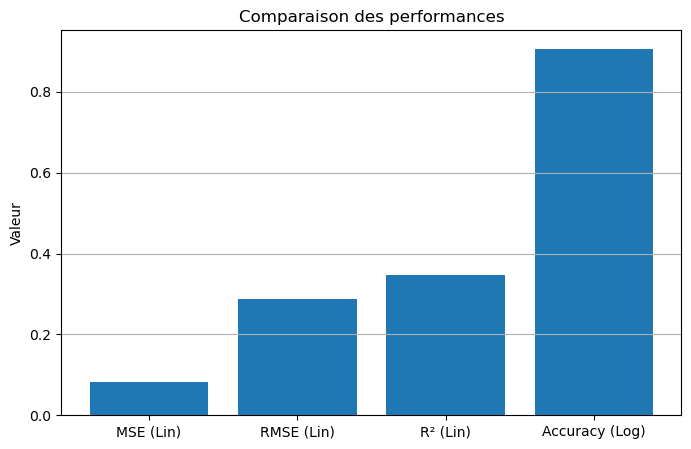

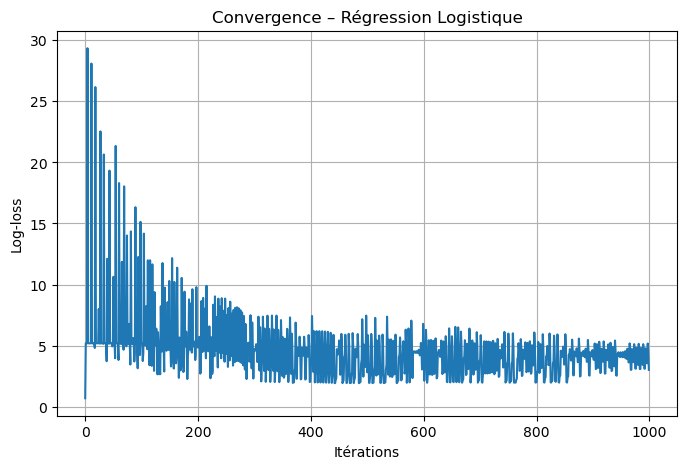

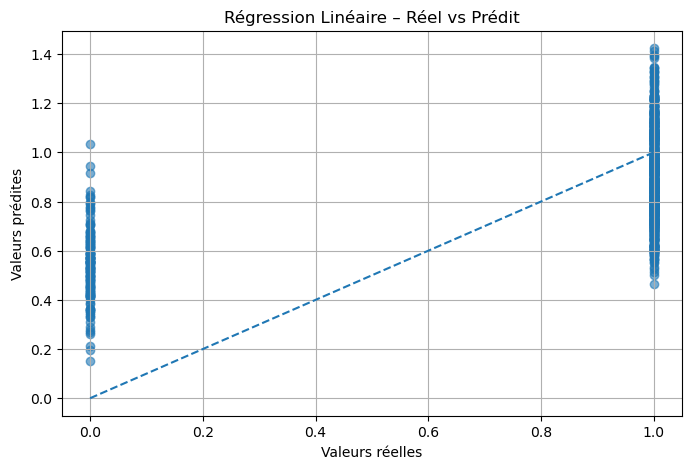

In [1]:
# ======================================================
# COMPARAISON : REGRESSION LINEAIRE vs LOGISTIQUE
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1️⃣ Chargement des données
# ------------------------------------------------
X_train = pd.read_csv("X_train.csv").apply(pd.to_numeric, errors="coerce").fillna(0).values
y_train = pd.read_csv("y_train.csv").apply(pd.to_numeric, errors="coerce").fillna(0).values.ravel()

X_test = pd.read_csv("X_test.csv").apply(pd.to_numeric, errors="coerce").fillna(0).values
y_test = pd.read_csv("y_test.csv").apply(pd.to_numeric, errors="coerce").fillna(0).values.ravel()

# Ajout du biais
def add_bias(X):
    return np.c_[np.ones((X.shape[0], 1)), X]

X_train_b = add_bias(X_train)
X_test_b = add_bias(X_test)

# ------------------------------------------------
# 2️⃣ RÉGRESSION LINÉAIRE (équation normale)
# ------------------------------------------------
theta_lin = np.linalg.pinv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

y_pred_lin = X_test_b @ theta_lin

# Métriques régression
mse_lin = np.mean((y_test - y_pred_lin) ** 2)
rmse_lin = np.sqrt(mse_lin)

ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
ss_res = np.sum((y_test - y_pred_lin) ** 2)
r2_lin = 1 - ss_res / ss_total

# ------------------------------------------------
# 3️⃣ RÉGRESSION LOGISTIQUE (Gradient Descent)
# ------------------------------------------------
class LogisticRegressionScratch:
    def __init__(self, lr=0.1, iterations=1000):
        self.lr = lr
        self.iterations = iterations
        self.weights = None
        self.cost_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        m = len(y)

        for _ in range(self.iterations):
            y_pred = self.sigmoid(X @ self.weights)
            cost = -(1/m) * np.sum(
                y * np.log(y_pred + 1e-15) + (1-y) * np.log(1 - y_pred + 1e-15)
            )
            self.cost_history.append(cost)
            gradient = (1/m) * X.T @ (y_pred - y)
            self.weights -= self.lr * gradient

    def predict_proba(self, X):
        return self.sigmoid(X @ self.weights)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

# Entraînement
log_model = LogisticRegressionScratch()
log_model.fit(X_train_b, y_train)

y_pred_log = log_model.predict(X_test_b)

accuracy_log = np.mean(y_pred_log == y_test)

# ------------------------------------------------
# 4️⃣ COMPARAISON DES MÉTRIQUES
# ------------------------------------------------
print("\n📊 COMPARAISON DES MODELES")
print("Régression Linéaire :")
print(f"  MSE  = {mse_lin:.4f}")
print(f"  RMSE = {rmse_lin:.4f}")
print(f"  R²   = {r2_lin:.4f}")

print("\nRégression Logistique :")
print(f"  Accuracy = {accuracy_log*100:.2f}%")

# ------------------------------------------------
# 5️⃣ GRAPHIQUE 1 : Comparaison des métriques
# ------------------------------------------------
plt.figure(figsize=(8, 5))
plt.bar(["MSE (Lin)", "RMSE (Lin)", "R² (Lin)", "Accuracy (Log)"],
        [mse_lin, rmse_lin, r2_lin, accuracy_log])
plt.title("Comparaison des performances")
plt.ylabel("Valeur")
plt.grid(axis="y")
plt.show()

# ------------------------------------------------
# 6️⃣ GRAPHIQUE 2 : Convergence Logistique
# ------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(log_model.cost_history)
plt.xlabel("Itérations")
plt.ylabel("Log-loss")
plt.title("Convergence – Régression Logistique")
plt.grid(True)
plt.show()

# ------------------------------------------------
# 7️⃣ GRAPHIQUE 3 : Réel vs Prédit (Linéaire)
# ------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_lin, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Régression Linéaire – Réel vs Prédit")
plt.grid(True)
plt.show()
